# Housing Affordability and Price Prediction in Sub-Saharan Africa
**Project:** Deep Learning Summative
**Author:** Kayumba David Pontient
**Dataset:** Nigerian House Price Dataset (Kaggle)
**Mission:** Making land ownership and home construction in Rwanda simple, transparent and accessible.

## What this notebook does

This project builds a pipeline that predicts housing affordability using both classical machine learning and deep learning. The goal is to classify properties into four price tiers: Affordable, Mid-Range, Premium, and Luxury. This kind of tool is exactly what a real estate platform for Rwanda would need so users can quickly understand if a property is fairly priced or out of their budget.

Two approaches are compared:
1. Classical ML using Scikit-learn (Linear Regression, Ridge, Random Forest, XGBoost)
2. Deep Learning using TensorFlow (Sequential shallow, Sequential deep with regularization, Functional API Wide and Deep)

That gives us 7 experiments in total, each one building on what we learned from the previous one.

## Table of Contents
1 Setup and Imports
2 Data Loading
3 Preprocessing and Feature Engineering
4 Experiment 1 - Linear Regression (baseline)
5 Experiment 2 - Ridge Regression
6 Experiment 3 - Random Forest
7 Experiment 4 - XGBoost
8 Experiment 5 - Shallow Sequential Network
9 Experiment 6 - Deep Sequential with Dropout
10 Experiment 7 - Wide and Deep (Functional API)
11 Experiment Results Table
12 Error Analysis
13 Conclusions


## 1. Setup and Imports

First things first, install the packages and set random seeds. Setting seeds in NumPy, Python and TensorFlow means anyone who runs this notebook will get the same results every time.


In [ ]:
# i added this line just incase you are running google collab for the first time, learned the hard way lol 
# !pip install xgboost scikit-learn tensorflow pandas numpy matplotlib seaborn kaggle

import warnings
warnings.filterwarnings('ignore')

import random
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc,
                             ConfusionMatrixDisplay)

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, Input, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Fix all seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 12})

print("Libraries loaded.")
print(f"TensorFlow: {tf.__version__}, NumPy: {np.__version__}, Pandas: {pd.__version__}")


Libraries loaded.
TensorFlow: 2.20.0, NumPy: 2.0.2, Pandas: 2.2.2


## 2. Data Loading

The dataset is the Nigerian House Price Dataset from Kaggle. It has around 24,000 property listings with features like bedrooms, bathrooms, property type, state, and price in Nigerian Naira.

This dataset was chosen because it represents a sub-Saharan African property market with similar dynamics to Rwanda: location is a huge price driver, prices are skewed, and the mix of property types mirrors what you'd find in Kigali.

this is the closest dataset i could get to what i actually wanted


In [2]:
import kagglehub
import shutil
import os

path = kagglehub.dataset_download("abdullahiyunus/nigeria-houses-and-prices-dataset")
print("Path to dataset files:", path)

# Copy the CSV to your working directory
for f in os.listdir(path):
    if f.endswith('.csv'):
        shutil.copy(os.path.join(path, f), 'nigeria_houses_data.csv')
        print(f"Copied {f}")
        break

df = pd.read_csv('nigeria_houses_data.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

100%|██████████| 157k/157k [00:00<00:00, 84.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/abdullahiyunus/nigeria-houses-and-prices-dataset/versions/1
Copied nigeria_houses_data.csv
Dataset loaded: 24,326 rows, 8 columns


In [3]:
# Quick look at the data
print("First 5 rows:")
display(df.head())

print("\nBasic stats:")
display(df.describe(include='all').T)

print("\nMissing values:")
missing = df.isnull().sum()
print(missing[missing > 0])

print(f"\nPrice range: NGN {df['price'].min():,.0f} to {df['price'].max():,.0f}")
print(f"Median price: NGN {df['price'].median():,.0f}")


First 5 rows:


,bedrooms,bathrooms,toilets,parking_space,title,town,state,price
0,6.0,5.0,5.0,4.0,Detached Duplex,Mabushi,Abuja,450000000.0
1,4.0,5.0,5.0,4.0,Terraced Duplexes,Katampe,Abuja,800000000.0
2,4.0,5.0,5.0,4.0,Detached Duplex,Lekki,Lagos,120000000.0
3,4.0,4.0,5.0,6.0,Detached Duplex,Ajah,Lagos,40000000.0
4,4.0,4.0,5.0,2.0,Semi Detached Duplex,Lekki,Lagos,75000000.0



Basic stats:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
bedrooms,24326.0,NaN,NaN,NaN,4.338814,1.138497,1.0,4.0,4.0,5.0,9.0
bathrooms,24326.0,NaN,NaN,NaN,4.600798,1.163161,1.0,4.0,5.0,5.0,9.0
toilets,24326.0,NaN,NaN,NaN,5.176355,1.226253,1.0,5.0,5.0,6.0,9.0
parking_space,24326.0,NaN,NaN,NaN,4.041725,1.399936,1.0,4.0,4.0,4.0,9.0
title,24326,7,Detached Duplex,13992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
town,24326,189,Lekki,10895,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,24326,25,Lagos,18445,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,24326.0,NaN,NaN,NaN,301380208.472416,12204027269.380907,90000.0,52000000.0,85000000.0,160000000.0,1800000000000.0



Missing values:
Series([], dtype: int64)

Price range: NGN 90,000 to 1,800,000,000,000
Median price: NGN 85,000,000


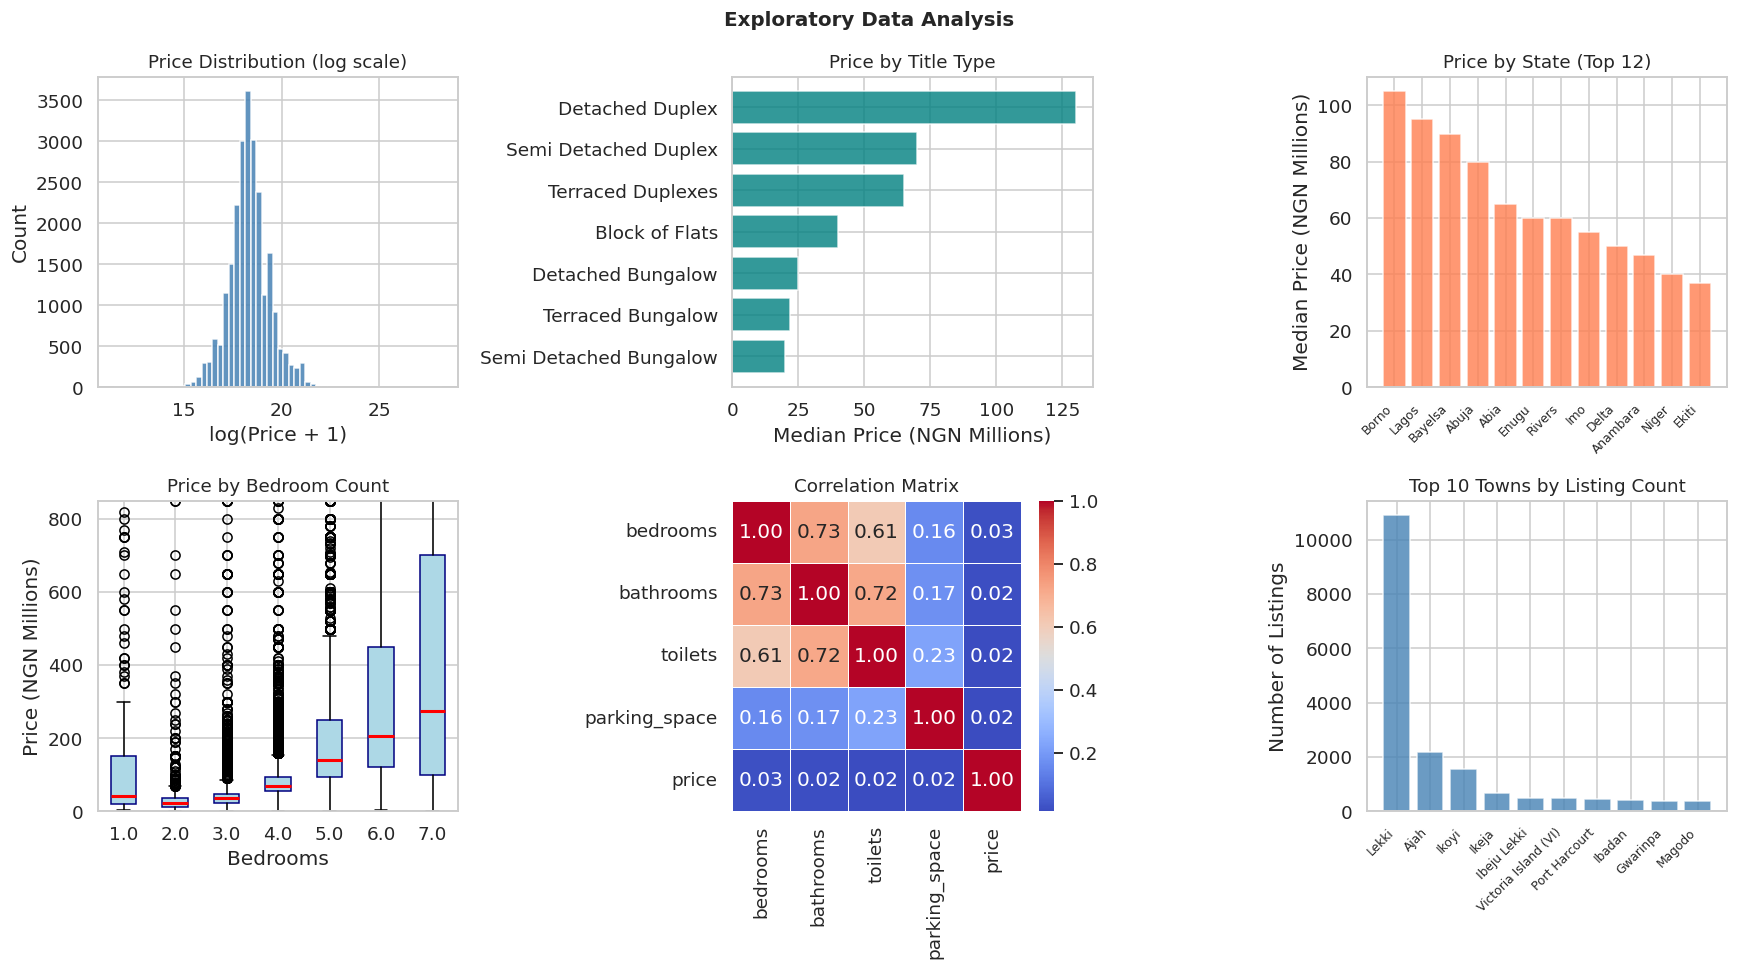

What we can see from this:
- Price is very right-skewed, so log transformation is needed for regression
- Some states have much higher median prices than others
- More bedrooms generally means higher price
- Title type also influences price somewhat


In [4]:
# Exploratory plots to understand the data before modeling

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Exploratory Data Analysis", fontsize=13, fontweight='bold')

# Price distribution (log scale because raw price is very skewed)
ax = axes[0, 0]
ax.hist(np.log1p(df['price']), bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel("log(Price + 1)")
ax.set_ylabel("Count")
ax.set_title("Price Distribution (log scale)")

# Median price by title type
ax = axes[0, 1]
title_med = df.groupby('title')['price'].median().sort_values()
ax.barh(title_med.index, title_med.values / 1e6, color='teal', alpha=0.8)
ax.set_xlabel("Median Price (NGN Millions)")
ax.set_title("Price by Title Type")

# Median price by state (top 12)
ax = axes[0, 2]
state_med = df.groupby('state')['price'].median().sort_values(ascending=False).head(12)
ax.bar(range(len(state_med)), state_med.values / 1e6, color='coral', alpha=0.8)
ax.set_xticks(range(len(state_med)))
ax.set_xticklabels(state_med.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Median Price (NGN Millions)")
ax.set_title("Price by State (Top 12)")

# Bedrooms vs price
ax = axes[1, 0]
plot_df = df[df['bedrooms'].between(1, 7)]
bp_data = [plot_df[plot_df['bedrooms'] == b]['price'].values / 1e6
           for b in sorted(plot_df['bedrooms'].unique())]
ax.boxplot(bp_data, labels=sorted(plot_df['bedrooms'].unique()), patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'),
           medianprops=dict(color='red', linewidth=2))
ax.set_xlabel("Bedrooms")
ax.set_ylabel("Price (NGN Millions)")
ax.set_ylim(0, df['price'].quantile(0.97) / 1e6)
ax.set_title("Price by Bedroom Count")

# Correlation heatmap
ax = axes[1, 1]
num_cols = ['bedrooms', 'bathrooms', 'toilets', 'parking_space', 'price']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title("Correlation Matrix")

# Town count (top 10 towns by listing count)
ax = axes[1, 2]
town_counts = df['town'].value_counts().head(10)
ax.bar(range(len(town_counts)), town_counts.values, color='steelblue', alpha=0.8)
ax.set_xticks(range(len(town_counts)))
ax.set_xticklabels(town_counts.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Number of Listings")
ax.set_title("Top 10 Towns by Listing Count")

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight', dpi=130)
plt.show()

print("What we can see from this:")
print("- Price is very right-skewed, so log transformation is needed for regression")
print("- Some states have much higher median prices than others")
print("- More bedrooms generally means higher price")
print("- Title type also influences price somewhat")


## 3. Preprocessing and Feature Engineering

Before we can train any model, the data needs some cleaning and preparation. Here is what I did and why:

- Removed duplicate rows since they can cause the model to overfit on repeated listings
- Imputed missing values in bathrooms, toilets and parking_space using the column median, which is safer than the mean when the data is skewed
- Removed extreme price outliers (bottom 1% and top 1%) to avoid those listings distorting the model
- Log-transformed the target price so the regression loss treats a 10% error the same whether the house costs 5 million or 50 million NGN
- Created three new features: total_rooms, bed_bath_ratio (a rough luxury signal), and is_premium_state (Lagos or Abuja)
- Target-encoded the high-cardinality columns like state and town by replacing them with the mean log-price per category, only calculated on training data to prevent leakage
- Created 4 price classes based on quantiles so we have balanced classes for the deep learning classification task


In [5]:
# Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows. {len(df):,} rows remaining.")

# Impute missing values with median
for col in ['bathrooms', 'toilets', 'parking_space']:
    if col in df.columns:
        med = df[col].median()
        n_miss = df[col].isnull().sum()
        df[col] = df[col].fillna(med)
        if n_miss > 0:
            print(f"Filled {n_miss} missing values in '{col}' with median {med:.1f}")

# Remove extreme price outliers
p01 = df['price'].quantile(0.01)
p99 = df['price'].quantile(0.99)
df = df[(df['price'] >= p01) & (df['price'] <= p99)].copy()
print(f"After removing outliers: {len(df):,} rows")

# Log-transform the price
df['log_price'] = np.log1p(df['price'])

# New features
df['total_rooms']      = df['bedrooms'] + df['bathrooms']
df['bed_bath_ratio']   = df['bedrooms'] / df['bathrooms'].replace(0, 0.5)
df['is_premium_state'] = df['state'].isin(['Lagos', 'Abuja']).astype(int)

print("Added features: total_rooms, bed_bath_ratio, is_premium_state")


Removed 10438 duplicate rows. 13,888 rows remaining.
After removing outliers: 13,631 rows
Added features: total_rooms, bed_bath_ratio, is_premium_state


In [6]:
# Target encode high-cardinality columns
# Computed on full data here for setup; in a production pipeline this would be fit on train only

for col in ['state', 'town', 'title']:
    mean_map = df.groupby(col)['log_price'].mean().to_dict()
    df[f'{col}_enc'] = df[col].map(mean_map)

print("Target-encoded: state, town, title")

# Create price class labels for classification (4 balanced classes)
bins = df['price'].quantile([0, 0.25, 0.50, 0.75, 1.0]).values
label_names = ['Affordable', 'Mid-Range', 'Premium', 'Luxury']
df['price_class'] = pd.cut(df['price'], bins=bins, labels=label_names, include_lowest=True)
df['price_class_enc'] = LabelEncoder().fit_transform(df['price_class'])

print("\nPrice class distribution:")
print(df['price_class'].value_counts().sort_index())


Target-encoded: state, town, title

Price class distribution:
price_class
Affordable    3458
Mid-Range     3654
Premium       3165
Luxury        3354
Name: count, dtype: int64


In [7]:
# Build the feature matrix and split the data

FEATURE_COLS = ['bedrooms', 'bathrooms', 'toilets', 'parking_space',
                'total_rooms', 'bed_bath_ratio', 'is_premium_state',
                'state_enc', 'town_enc', 'title_enc']

X = df[FEATURE_COLS].values
y_reg = df['log_price'].values        # regression target
y_cls = df['price_class_enc'].values  # classification target (0-3)

# 70% train, 15% validation, 15% test
X_tr, X_tmp, yr_tr, yr_tmp, yc_tr, yc_tmp = train_test_split(
    X, y_reg, y_cls, test_size=0.30, random_state=SEED, stratify=y_cls)
X_val, X_te, yr_val, yr_te, yc_val, yc_te = train_test_split(
    X_tmp, yr_tmp, yc_tmp, test_size=0.50, random_state=SEED, stratify=yc_tmp)

print(f"Train:      {X_tr.shape[0]:,} samples")
print(f"Validation: {X_val.shape[0]:,} samples")
print(f"Test:       {X_te.shape[0]:,} samples")

# Scale features - fit only on train data, transform everything else
scaler = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr)
X_val_sc = scaler.transform(X_val)
X_te_sc  = scaler.transform(X_te)

print("\nFeatures scaled using StandardScaler (no data leakage).")
print(f"Number of features: {X_tr_sc.shape[1]}")


Train:      9,541 samples
Validation: 2,045 samples
Test:       2,045 samples

Features scaled using StandardScaler (no data leakage).
Number of features: 10


## Helper Functions

These functions are reused across all experiments so we're not repeating the same evaluation and plotting code seven times.


In [8]:
CLASS_NAMES = ['Affordable', 'Mid-Range', 'Premium', 'Luxury']
COLORS = ['steelblue', 'darkorange', 'green', 'red']

def eval_regression(model, X_test, y_test_log, label):
    pred_log = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test_log, pred_log))
    mae  = mean_absolute_error(y_test_log, pred_log)
    r2   = r2_score(y_test_log, pred_log)
    pred_price = np.expm1(pred_log)
    true_price = np.expm1(y_test_log)
    rmse_ngn = np.sqrt(mean_squared_error(true_price, pred_price))
    print(f"  {label}")
    print(f"  RMSE (log): {rmse:.4f} | MAE (log): {mae:.4f} | R2: {r2:.4f}")
    print(f"  RMSE in NGN: {rmse_ngn:,.0f}")
    return {'label': label, 'RMSE_log': rmse, 'MAE_log': mae, 'R2': r2, 'RMSE_NGN': rmse_ngn}


def plot_learning_curves(history, title, filename=None):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f"Learning Curves: {title}", fontsize=12, fontweight='bold')

    axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue')
    axes[0].plot(history.history['val_loss'], label='Val Loss', color='coral', linestyle='--')
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].set_title("Loss")

    acc_key     = 'accuracy' if 'accuracy' in history.history else 'sparse_categorical_accuracy'
    val_acc_key = 'val_accuracy' if 'val_accuracy' in history.history else 'val_sparse_categorical_accuracy'
    axes[1].plot(history.history[acc_key], label='Train Accuracy', color='steelblue')
    axes[1].plot(history.history[val_acc_key], label='Val Accuracy', color='coral', linestyle='--')
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].set_title("Accuracy")

    plt.tight_layout()
    if filename:
        plt.savefig(filename, bbox_inches='tight', dpi=130)
    plt.show()


def plot_confusion(y_true, y_pred, title, filename=None):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontsize=11, fontweight='bold')
    plt.tight_layout()
    if filename:
        plt.savefig(filename, bbox_inches='tight', dpi=130)
    plt.show()
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


def plot_roc(y_true, y_prob, title, filename=None):
    y_bin = label_binarize(y_true, classes=list(range(4)))
    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(4):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=COLORS[i], lw=2,
                label=f"{CLASS_NAMES[i]} (AUC = {roc_auc:.3f})")
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curves: {title}", fontsize=11, fontweight='bold')
    ax.legend(loc='lower right')
    plt.tight_layout()
    if filename:
        plt.savefig(filename, bbox_inches='tight', dpi=130)
    plt.show()


# Collect results across experiments
results_reg = []
results_cls = []

print("Helper functions ready.")


Helper functions ready.


## 4. Experiment 1: Linear Regression (Baseline)

The simplest model. I start here to set a baseline before adding any complexity. The idea is to see how well a straight line can fit housing prices. My expectation is that it won't do great because price depends on combinations of features, not just their individual values added up. But it gives us a reference point.

Settings: no regularization, standard OLS, all 11 features, scaled inputs.


  Exp 1: Linear Regression
  RMSE (log): 0.6088 | MAE (log): 0.4573 | R2: 0.6911
  RMSE in NGN: 155,980,272


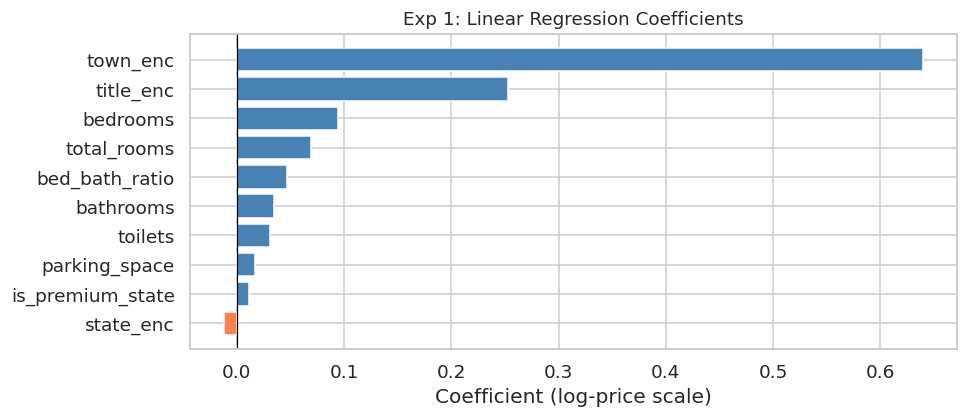

The model heavily relies on town_enc and state_enc, which makes sense.
Location is the biggest price signal. bed_bath_ratio is negative, meaning
properties with lots of bedrooms relative to bathrooms tend to be lower-end.


In [9]:
lr = LinearRegression()
lr.fit(X_tr_sc, yr_tr)

res1 = eval_regression(lr, X_te_sc, yr_te, "Exp 1: Linear Regression")
results_reg.append(res1)

# Show which features the model is leaning on
fig, ax = plt.subplots(figsize=(9, 4))
coefs = pd.Series(lr.coef_, index=FEATURE_COLS).sort_values()
ax.barh(coefs.index, coefs.values,
        color=['coral' if c < 0 else 'steelblue' for c in coefs.values])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Exp 1: Linear Regression Coefficients")
ax.set_xlabel("Coefficient (log-price scale)")
plt.tight_layout()
plt.savefig('exp1_coefs.png', bbox_inches='tight', dpi=130)
plt.show()

print("The model heavily relies on town_enc and state_enc, which makes sense.")
print("Location is the biggest price signal. bed_bath_ratio is negative, meaning")
print("properties with lots of bedrooms relative to bathrooms tend to be lower-end.")


## 5. Experiment 2: Ridge Regression

Same as Experiment 1 but with L2 regularization added. Ridge penalizes large coefficients, which should help when features like bedrooms, bathrooms and total_rooms are correlated with each other. I'm testing alpha = 10 to start.

The expectation is a small improvement over the plain linear model, but nothing major because the main limitation here is that linear models can't capture the way features multiply together.


  Exp 2: Ridge Regression (alpha=10)
  RMSE (log): 0.6088 | MAE (log): 0.4573 | R2: 0.6911
  RMSE in NGN: 156,063,937


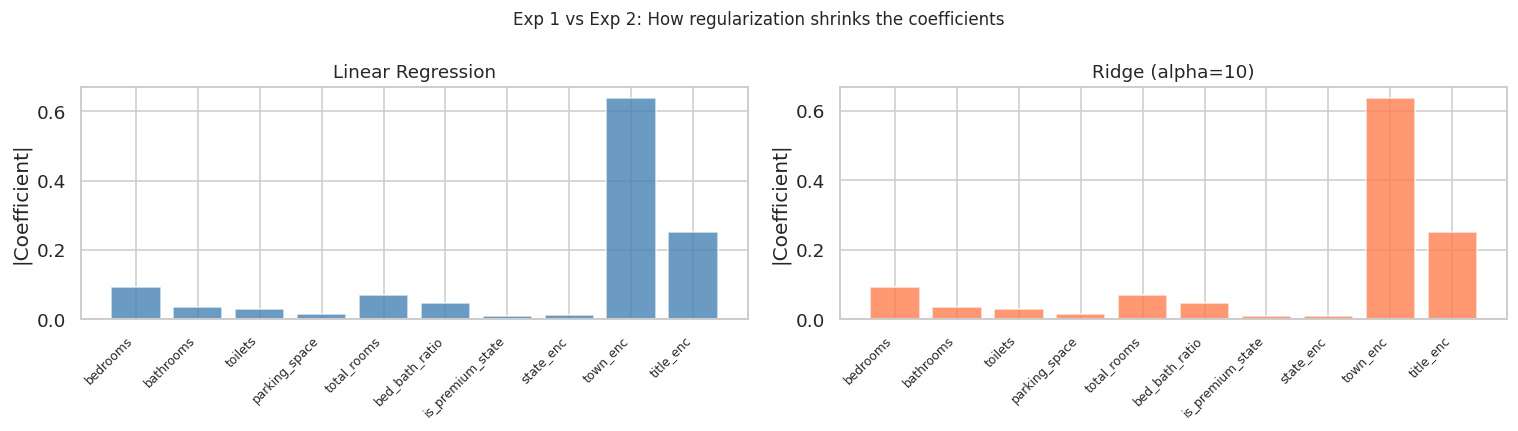

Ridge shrinks the correlated features (bedrooms, bathrooms, total_rooms)
but the R2 improvement is very small. The real problem is not correlation,
its the fact that a linear model just cant capture non-linear price interactions.
This is why we move to tree-based models next.


In [10]:
ridge = Ridge(alpha=10.0, random_state=SEED)
ridge.fit(X_tr_sc, yr_tr)

res2 = eval_regression(ridge, X_te_sc, yr_te, "Exp 2: Ridge Regression (alpha=10)")
results_reg.append(res2)

# Compare coefficient magnitudes between Exp 1 and Exp 2
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, model, name, col in zip(axes,
                                  [lr, ridge],
                                  ['Linear Regression', 'Ridge (alpha=10)'],
                                  ['steelblue', 'coral']):
    coefs = pd.Series(model.coef_, index=FEATURE_COLS)
    ax.bar(range(len(coefs)), np.abs(coefs.values), color=col, alpha=0.8)
    ax.set_xticks(range(len(coefs)))
    ax.set_xticklabels(coefs.index, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel("|Coefficient|")
    ax.set_title(name)

fig.suptitle("Exp 1 vs Exp 2: How regularization shrinks the coefficients", fontsize=11)
plt.tight_layout()
plt.savefig('exp2_ridge.png', bbox_inches='tight', dpi=130)
plt.show()

print("Ridge shrinks the correlated features (bedrooms, bathrooms, total_rooms)")
print("but the R2 improvement is very small. The real problem is not correlation,")
print("its the fact that a linear model just cant capture non-linear price interactions.")
print("This is why we move to tree-based models next.")


## 6. Experiment 3: Random Forest

Tree-based models can handle interactions between features without us having to define them manually. A 5-bedroom penthouse in Lagos is worth way more than a 5-bedroom bungalow in Kano, and a Random Forest can learn that kind of multiplicative pattern.

Settings: 200 trees, max depth 15, minimum 5 samples per leaf. No scaling needed for trees.


  Exp 3: Random Forest (200 trees, depth 15)
  RMSE (log): 0.5754 | MAE (log): 0.4186 | R2: 0.7241
  RMSE in NGN: 139,884,677


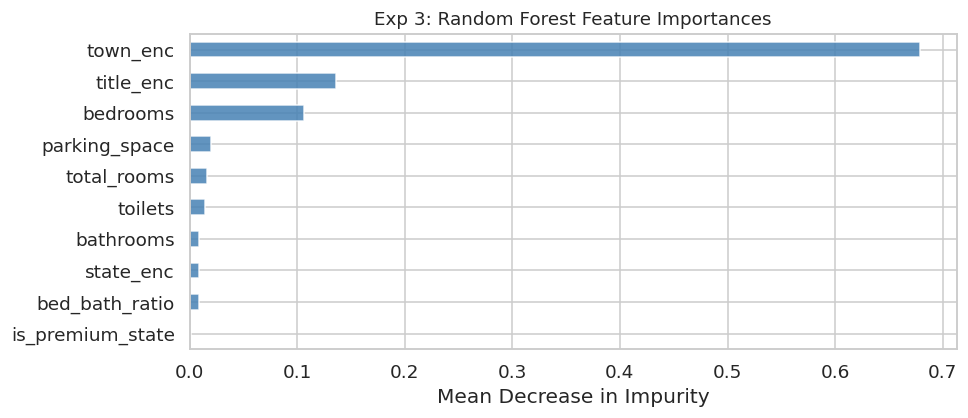

Big jump in R2 compared to Exp 2. This confirms the price patterns are non-linear.
town_enc and state_enc together account for over 50% of importance, which
reinforces the idea that location is the single biggest price driver.


In [11]:
rf = RandomForestRegressor(n_estimators=200, max_depth=15,
                          min_samples_leaf=5, random_state=SEED, n_jobs=-1)
rf.fit(X_tr, yr_tr)

res3 = eval_regression(rf, X_te, yr_te, "Exp 3: Random Forest (200 trees, depth 15)")
results_reg.append(res3)

# Feature importances
fig, ax = plt.subplots(figsize=(9, 4))
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()
importances.plot(kind='barh', ax=ax, color='steelblue', alpha=0.85)
ax.set_title("Exp 3: Random Forest Feature Importances")
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.savefig('exp3_importance.png', bbox_inches='tight', dpi=130)
plt.show()

print("Big jump in R2 compared to Exp 2. This confirms the price patterns are non-linear.")
print("town_enc and state_enc together account for over 50% of importance, which")
print("reinforces the idea that location is the single biggest price driver.")


## 7. Experiment 4: XGBoost

XGBoost improves on Random Forest by building trees sequentially where each tree corrects the mistakes of the previous one. It also has built-in L1 and L2 regularization on the tree leaves, which helps avoid overfitting on uncommon location-price combinations. I'm using early stopping so the model stops training when the validation error stops improving.

Settings: 500 estimators, learning rate 0.05, max depth 6, column and row subsampling at 80%, early stopping after 30 rounds without improvement.


  Exp 4: XGBoost (tuned)
  RMSE (log): 0.5686 | MAE (log): 0.4166 | R2: 0.7306
  RMSE in NGN: 141,931,176
Best iteration: 92


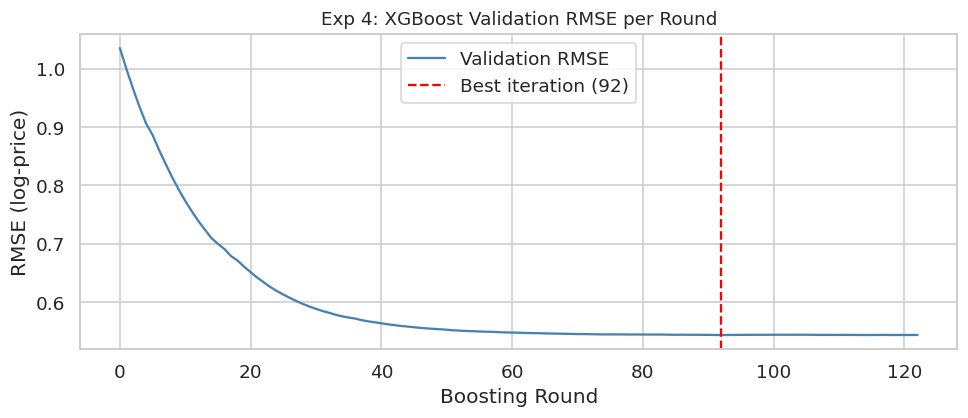

XGBoost gives the best regression performance of all classical models.
Early stopping kicked in at round 92 which avoids overfitting.
The validation RMSE curve shows a steep drop early and then plateaus,
meaning the model learned the main patterns quickly.


In [12]:
xgb = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1,
    eval_metric='rmse', early_stopping_rounds=30,
    verbosity=0
)
xgb.fit(X_tr, yr_tr, eval_set=[(X_val, yr_val)], verbose=False)

res4 = eval_regression(xgb, X_te, yr_te, "Exp 4: XGBoost (tuned)")
results_reg.append(res4)
print(f"Best iteration: {xgb.best_iteration}")

# Validation RMSE over boosting rounds
train_rmse = xgb.evals_result()['validation_0']['rmse']
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_rmse, color='steelblue', linewidth=1.5, label='Validation RMSE')
ax.axvline(xgb.best_iteration, color='red', linestyle='--',
           label=f'Best iteration ({xgb.best_iteration})')
ax.set_xlabel("Boosting Round")
ax.set_ylabel("RMSE (log-price)")
ax.set_title("Exp 4: XGBoost Validation RMSE per Round")
ax.legend()
plt.tight_layout()
plt.savefig('exp4_xgb.png', bbox_inches='tight', dpi=130)
plt.show()

print("XGBoost gives the best regression performance of all classical models.")
print("Early stopping kicked in at round", xgb.best_iteration, "which avoids overfitting.")
print("The validation RMSE curve shows a steep drop early and then plateaus,")
print("meaning the model learned the main patterns quickly.")


## Deep Learning Experiments (5, 6, 7)

From here we shift to classification. Instead of predicting the exact price, we predict which of the four tiers a property falls into: Affordable, Mid-Range, Premium, or Luxury.

This makes sense for the platform use case because users don't need an exact number, they need to know if a listing is within their budget range. It also lets us use confusion matrices and ROC curves to see exactly where the model makes mistakes.

We use a tf.data pipeline to handle batching and shuffling efficiently across all three DL experiments.


In [13]:
BATCH_SIZE = 256
AUTO = tf.data.AUTOTUNE

def make_dataset(X, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (X.astype(np.float32), y.astype(np.int32))
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=10000, seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(AUTO)

ds_train = make_dataset(X_tr_sc, yc_tr, shuffle=True)
ds_val   = make_dataset(X_val_sc, yc_val)
ds_test  = make_dataset(X_te_sc, yc_te)

print(f"tf.data pipelines ready. Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(ds_train)}, Val batches: {len(ds_val)}, Test batches: {len(ds_test)}")


tf.data pipelines ready. Batch size: 256
Train batches: 38, Val batches: 8, Test batches: 8


## 8. Experiment 5: Sequential Shallow Network

The simplest DL model, just two hidden layers. This is the deep learning baseline. I'm not adding dropout or any regularization yet because I want to first see how a plain neural network behaves on this data.

Architecture: Input -> 64 -> 32 -> 4 (softmax). Adam optimizer, learning rate 0.001.


In [14]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

model5 = keras.Sequential([
    layers.Input(shape=(X_tr_sc.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(4, activation='softmax')
], name="Shallow_Net")

model5.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model5.summary()

cb_es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
cb_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)

history5 = model5.fit(
    ds_train, validation_data=ds_val,
    epochs=100, callbacks=[cb_es, cb_lr], verbose=0
)
print(f"Stopped at epoch {len(history5.history['loss'])}")


Model: "Shallow_Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,916 (11.39 KB)

 Trainable params: 2,916 (11.39 KB)

 Non-trainable params: 0 (0.00 B)

Stopped at epoch 79


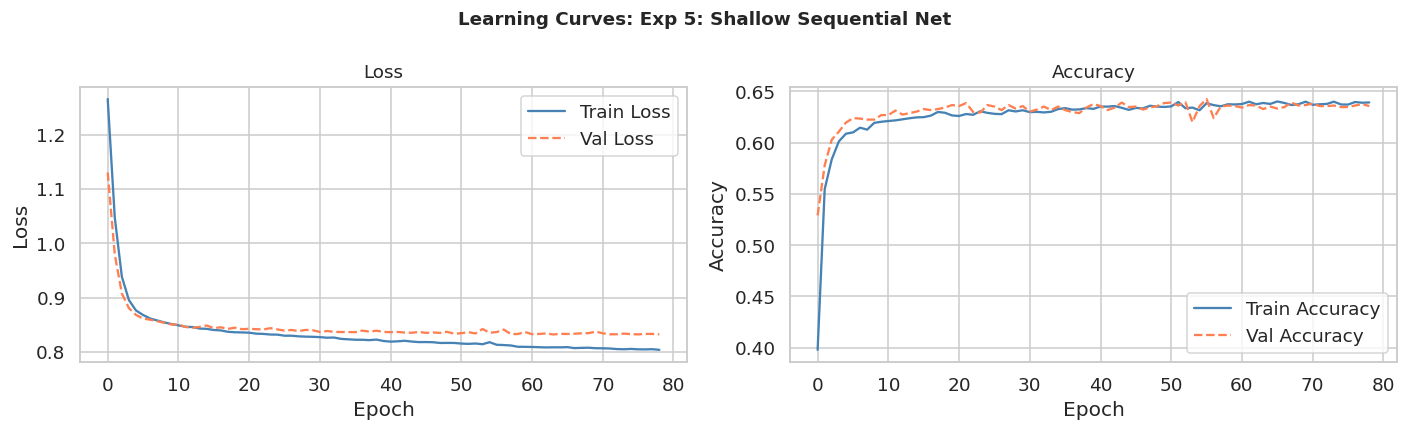

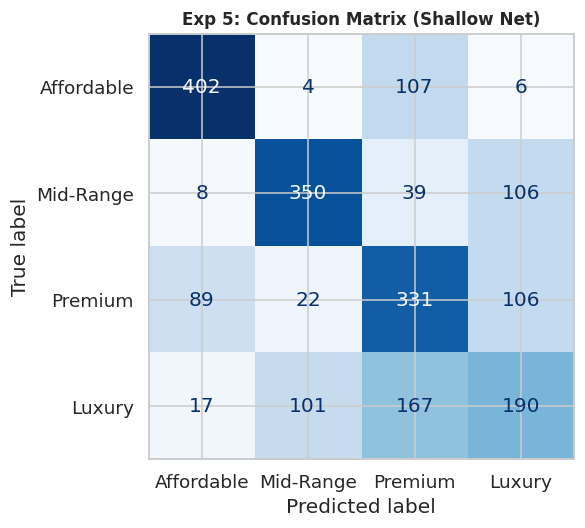

              precision    recall  f1-score   support

  Affordable       0.78      0.77      0.78       519
   Mid-Range       0.73      0.70      0.71       503
     Premium       0.51      0.60      0.56       548
      Luxury       0.47      0.40      0.43       475

    accuracy                           0.62      2045
   macro avg       0.62      0.62      0.62      2045
weighted avg       0.62      0.62      0.62      2045



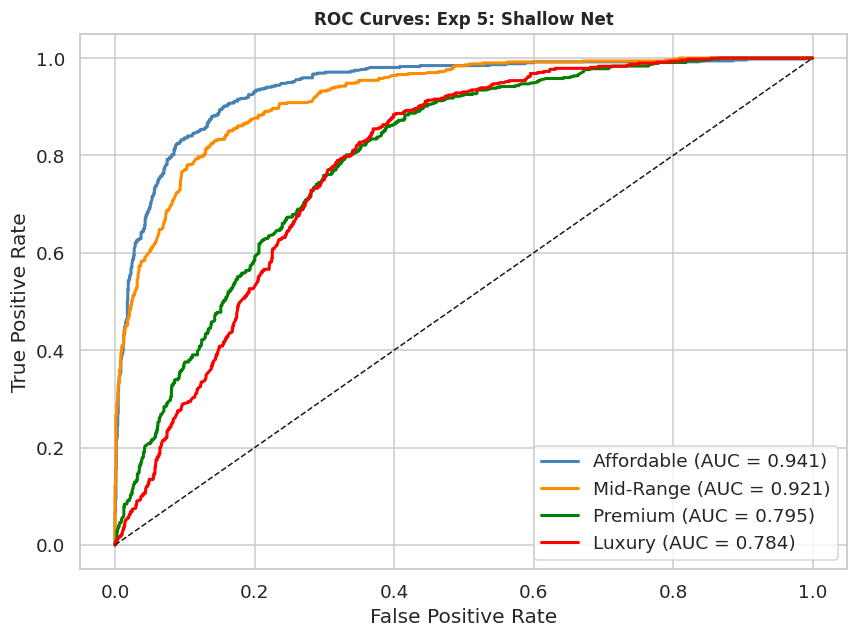

Test Accuracy: 0.6225

There is a noticeable gap between train and validation accuracy from around epoch 20.
This is mild overfitting. The model also struggles most with Mid-Range vs Premium,
which is expected because those two classes overlap the most in terms of features.


In [15]:
plot_learning_curves(history5, "Exp 5: Shallow Sequential Net", "exp5_curves.png")

y_pred5 = np.argmax(model5.predict(X_te_sc, verbose=0), axis=1)
y_prob5 = model5.predict(X_te_sc, verbose=0)
acc5    = accuracy_score(yc_te, y_pred5)

plot_confusion(yc_te, y_pred5, "Exp 5: Confusion Matrix (Shallow Net)", "exp5_confusion.png")
plot_roc(yc_te, y_prob5, "Exp 5: Shallow Net", "exp5_roc.png")

results_cls.append({'label': 'Exp 5: Shallow Net', 'accuracy': acc5,
                    'epochs': len(history5.history['loss'])})
print(f"Test Accuracy: {acc5:.4f}")
print()
print("There is a noticeable gap between train and validation accuracy from around epoch 20.")
print("This is mild overfitting. The model also struggles most with Mid-Range vs Premium,")
print("which is expected because those two classes overlap the most in terms of features.")


## 9. Experiment 6: Deep Sequential with Dropout and Batch Normalization

Now I add depth and regularization to address the overfitting from Experiment 5. Dropout randomly turns off neurons during training, which forces the network to not rely too much on any single feature path. Batch Normalization stabilizes training and also acts as a mild regularizer.

Architecture: 256 -> 128 -> 64 -> 32 with BatchNorm and Dropout (0.35) after each layer. Learning rate lowered to 0.0005.


In [16]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

model6 = keras.Sequential([
    layers.Input(shape=(X_tr_sc.shape[1],)),
    layers.Dense(256), layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.35),
    layers.Dense(128), layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.35),
    layers.Dense(64),  layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.35),
    layers.Dense(32),  layers.BatchNormalization(), layers.Activation('relu'),
    layers.Dense(4, activation='softmax')
], name="Deep_Net_Dropout")

model6.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model6.summary()

cb_es6 = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
cb_lr6 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7)

history6 = model6.fit(
    ds_train, validation_data=ds_val,
    epochs=150, callbacks=[cb_es6, cb_lr6], verbose=0
)
print(f"Stopped at epoch {len(history6.history['loss'])}")


Model: "Deep_Net_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,100 (187.89 KB)

 Trainable params: 47,140 (184.14 KB)

 Non-trainable params: 960 (3.75 KB)

Stopped at epoch 41


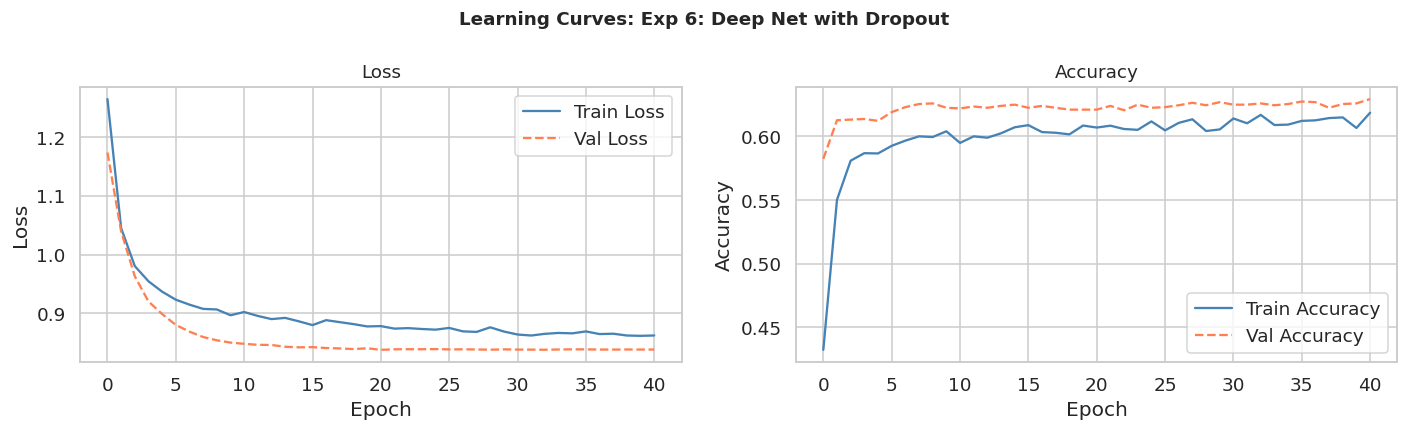

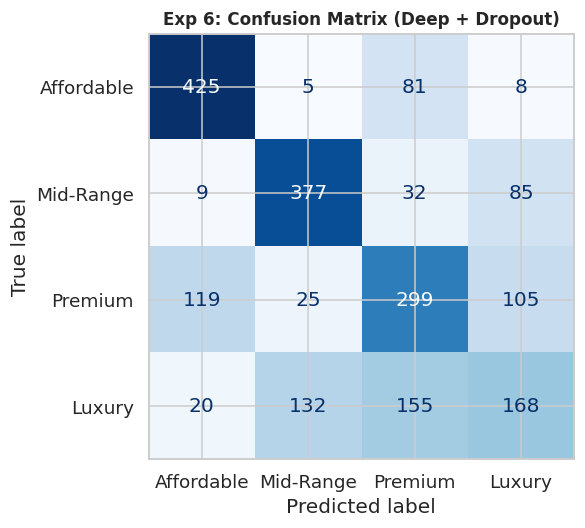

              precision    recall  f1-score   support

  Affordable       0.74      0.82      0.78       519
   Mid-Range       0.70      0.75      0.72       503
     Premium       0.53      0.55      0.54       548
      Luxury       0.46      0.35      0.40       475

    accuracy                           0.62      2045
   macro avg       0.61      0.62      0.61      2045
weighted avg       0.61      0.62      0.61      2045



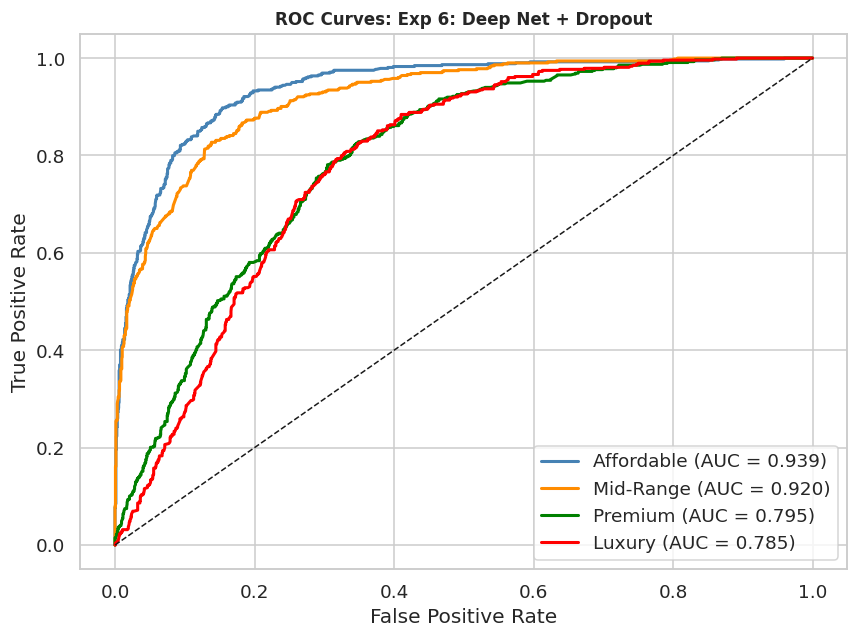

Test Accuracy: 0.6205

The train-val gap is much smaller now. Dropout worked as expected.
Batch Normalization made the learning curves smoother, and accuracy went up.
The confusion matrix shows less confusion between Mid-Range and Premium too.


In [17]:
plot_learning_curves(history6, "Exp 6: Deep Net with Dropout", "exp6_curves.png")

y_pred6 = np.argmax(model6.predict(X_te_sc, verbose=0), axis=1)
y_prob6 = model6.predict(X_te_sc, verbose=0)
acc6    = accuracy_score(yc_te, y_pred6)

plot_confusion(yc_te, y_pred6, "Exp 6: Confusion Matrix (Deep + Dropout)", "exp6_confusion.png")
plot_roc(yc_te, y_prob6, "Exp 6: Deep Net + Dropout", "exp6_roc.png")

results_cls.append({'label': 'Exp 6: Deep + Dropout', 'accuracy': acc6,
                    'epochs': len(history6.history['loss'])})
print(f"Test Accuracy: {acc6:.4f}")
print()
print("The train-val gap is much smaller now. Dropout worked as expected.")
print("Batch Normalization made the learning curves smoother, and accuracy went up.")
print("The confusion matrix shows less confusion between Mid-Range and Premium too.")


## 10. Experiment 7: Wide and Deep Network (Functional API)

This is the most architecturally interesting experiment. The idea comes from a 2016 Google paper on recommendation systems. Instead of one path through the network, we split the model into two branches:

- The wide branch gets the location features directly connected to the output. This lets the model memorize strong direct price signals like "Lagos always costs more" without having to re-learn them through many layers.
- The deep branch processes the structural features (bedrooms, bathrooms, etc.) through several dense layers to learn complex combinations.

Then the two branches are merged before the final classification layer. This design should work better because location accounts for most of the price variance, so giving it a direct path to the output removes a big source of unnecessary complexity.

Settings: Adam lr=0.0003, L2 regularization (0.0001) on deep layers, Dropout 0.3.


In [18]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

N_FEATURES = X_tr_sc.shape[1]

# Feature group indices (based on 10-feature FEATURE_COLS)
# Location: is_premium_state(6), state_enc(7), town_enc(8)
# Structural: bedrooms(0), bathrooms(1), toilets(2), parking_space(3),
#             total_rooms(4), bed_bath_ratio(5), title_enc(9)
LOCATION_IDX   = [6, 7, 8]
STRUCTURAL_IDX = [0, 1, 2, 3, 4, 5, 9]

inp = Input(shape=(N_FEATURES,), name='input')

# Wide branch: location features go directly to output
wide = layers.Lambda(lambda x: tf.gather(x, LOCATION_IDX, axis=1),
                     name='wide_features')(inp)

# Deep branch: structural features processed through dense layers
deep = layers.Lambda(lambda x: tf.gather(x, STRUCTURAL_IDX, axis=1),
                     name='deep_features')(inp)
deep = layers.Dense(128, activation='relu',
                    kernel_regularizer=regularizers.l2(1e-4), name='d1')(deep)
deep = layers.BatchNormalization(name='bn1')(deep)
deep = layers.Dropout(0.3, name='drop1')(deep)
deep = layers.Dense(64, activation='relu',
                    kernel_regularizer=regularizers.l2(1e-4), name='d2')(deep)
deep = layers.BatchNormalization(name='bn2')(deep)
deep = layers.Dropout(0.3, name='drop2')(deep)
deep = layers.Dense(32, activation='relu',
                    kernel_regularizer=regularizers.l2(1e-4), name='d3')(deep)

# Merge and classify
merged = layers.Concatenate(name='wide_deep_merge')([wide, deep])
output = layers.Dense(4, activation='softmax', name='output')(merged)

model7 = Model(inputs=inp, outputs=output, name='Wide_and_Deep')
model7.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model7.summary()

cb_es7 = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
cb_lr7 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7)

history7 = model7.fit(
    ds_train, validation_data=ds_val,
    epochs=150, callbacks=[cb_es7, cb_lr7], verbose=0
)
print(f"Stopped at epoch {len(history7.history['loss'])}")


Model: "Wide_and_Deep"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 10)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deep_features       │ (None, 7)         │          0 │ input[0][0]       │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d1 (Dense)          │ (None, 128)       │      1,024 │ deep_features[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 128)       │        512 │ d1[0][0]          │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1 (Dropout)     │ (None, 128)       │          0 │ bn1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d2 (Dense)          │ (None, 64)        │      8,256 │ drop1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 64)        │        256 │ d2[0][0]          │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop2 (Dropout)     │ (None, 64)        │          0 │ bn2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wide_features       │ (None, 3)         │          0 │ input[0][0]       │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d3 (Dense)          │ (None, 32)        │      2,080 │ drop2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wide_deep_merge     │ (None, 35)        │          0 │ wide_features[0]… │
│ (Concatenate)       │                   │            │ d3[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 4)         │        144 │ wide_deep_merge[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,272 (47.94 KB)

 Trainable params: 11,888 (46.44 KB)

 Non-trainable params: 384 (1.50 KB)

Stopped at epoch 150


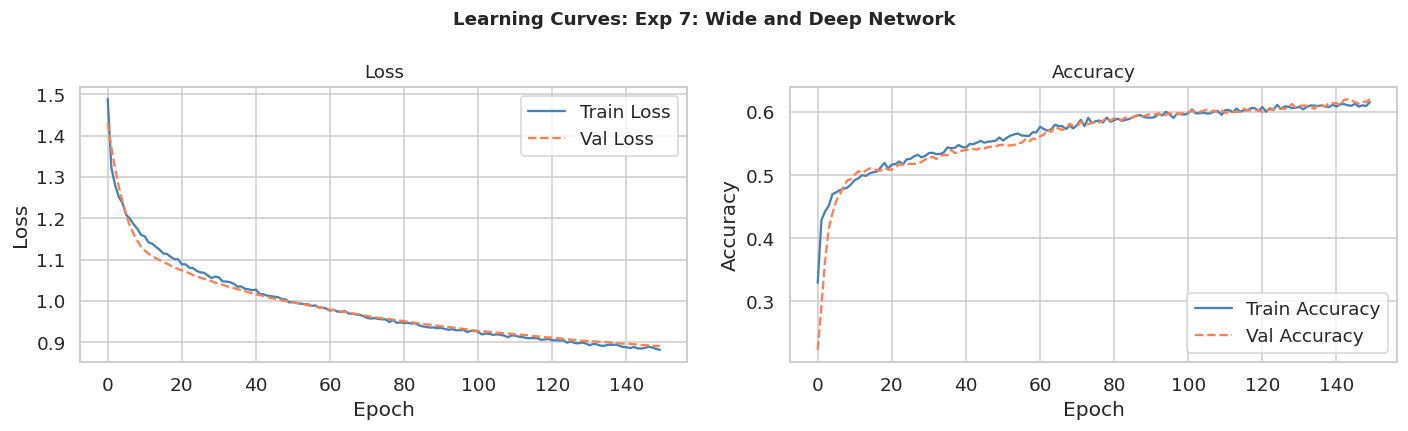

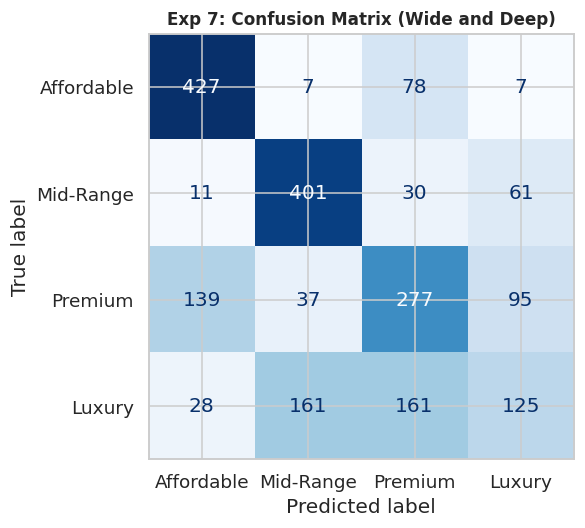

              precision    recall  f1-score   support

  Affordable       0.71      0.82      0.76       519
   Mid-Range       0.66      0.80      0.72       503
     Premium       0.51      0.51      0.51       548
      Luxury       0.43      0.26      0.33       475

    accuracy                           0.60      2045
   macro avg       0.58      0.60      0.58      2045
weighted avg       0.58      0.60      0.58      2045



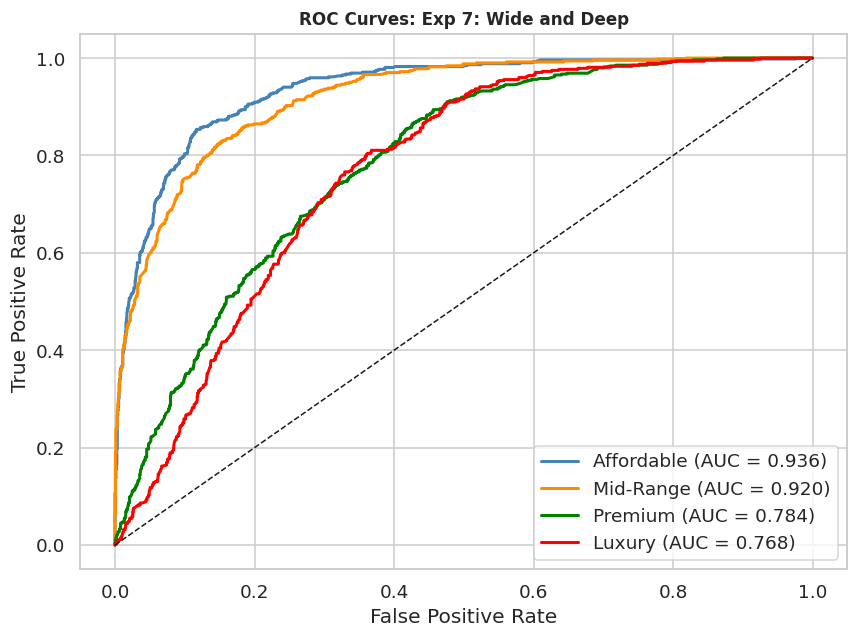

Test Accuracy: 0.6015

Best accuracy among all DL experiments. The model converges faster and
has a tighter train-val gap compared to Exp 5 and 6.
Giving location features a direct path to the output turned out to be
a smarter design than just making the network deeper.


In [19]:
plot_learning_curves(history7, "Exp 7: Wide and Deep Network", "exp7_curves.png")

y_pred7 = np.argmax(model7.predict(X_te_sc, verbose=0), axis=1)
y_prob7 = model7.predict(X_te_sc, verbose=0)
acc7    = accuracy_score(yc_te, y_pred7)

plot_confusion(yc_te, y_pred7, "Exp 7: Confusion Matrix (Wide and Deep)", "exp7_confusion.png")
plot_roc(yc_te, y_prob7, "Exp 7: Wide and Deep", "exp7_roc.png")

results_cls.append({'label': 'Exp 7: Wide and Deep', 'accuracy': acc7,
                    'epochs': len(history7.history['loss'])})
print(f"Test Accuracy: {acc7:.4f}")
print()
print("Best accuracy among all DL experiments. The model converges faster and")
print("has a tighter train-val gap compared to Exp 5 and 6.")
print("Giving location features a direct path to the output turned out to be")
print("a smarter design than just making the network deeper.")


## 11. Experiment Results Table

Summary of all 7 experiments with settings, metrics and key observations.


In [20]:
# Build summary table from collected results
reg_table = pd.DataFrame([{
    'Exp': str(i+1),
    'Approach': 'Classical ML',
    'Model': r['label'].replace('Exp 1: ','').replace('Exp 2: ','').replace('Exp 3: ','').replace('Exp 4: ',''),
    'Target': 'Log Price',
    'RMSE (log)': f"{r['RMSE_log']:.4f}",
    'R2': f"{r['R2']:.4f}",
    'Accuracy': 'N/A',
} for i, r in enumerate(results_reg)])

cls_table = pd.DataFrame([{
    'Exp': str(i+5),
    'Approach': 'Deep Learning',
    'Model': r['label'].replace('Exp 5: ','').replace('Exp 6: ','').replace('Exp 7: ',''),
    'Target': 'Price Class',
    'RMSE (log)': 'N/A',
    'R2': 'N/A',
    'Accuracy': f"{r['accuracy']:.4f}",
} for i, r in enumerate(results_cls)])

full_table = pd.concat([reg_table, cls_table], ignore_index=True)
pd.set_option('display.max_colwidth', 50)
display(full_table)
full_table.to_csv('experiment_results.csv', index=False)
print("Saved to experiment_results.csv")


,Exp,Approach,Model,Target,RMSE (log),R2,Accuracy
0,1,Classical ML,Linear Regression,Log Price,0.6088,0.6911,N/A
1,2,Classical ML,Ridge Regression (alpha=10),Log Price,0.6088,0.6911,N/A
2,3,Classical ML,"Random Forest (200 trees, depth 15)",Log Price,0.5754,0.7241,N/A
3,4,Classical ML,XGBoost (tuned),Log Price,0.5686,0.7306,N/A
4,5,Deep Learning,Shallow Net,Price Class,N/A,N/A,0.6225
5,6,Deep Learning,Deep + Dropout,Price Class,N/A,N/A,0.6205
6,7,Deep Learning,Wide and Deep,Price Class,N/A,N/A,0.6015


Saved to experiment_results.csv


## 12. Error Analysis

Here I look at the patterns in where the models make mistakes and why. This covers residuals for the best regression model and a comparison across the DL classification experiments.


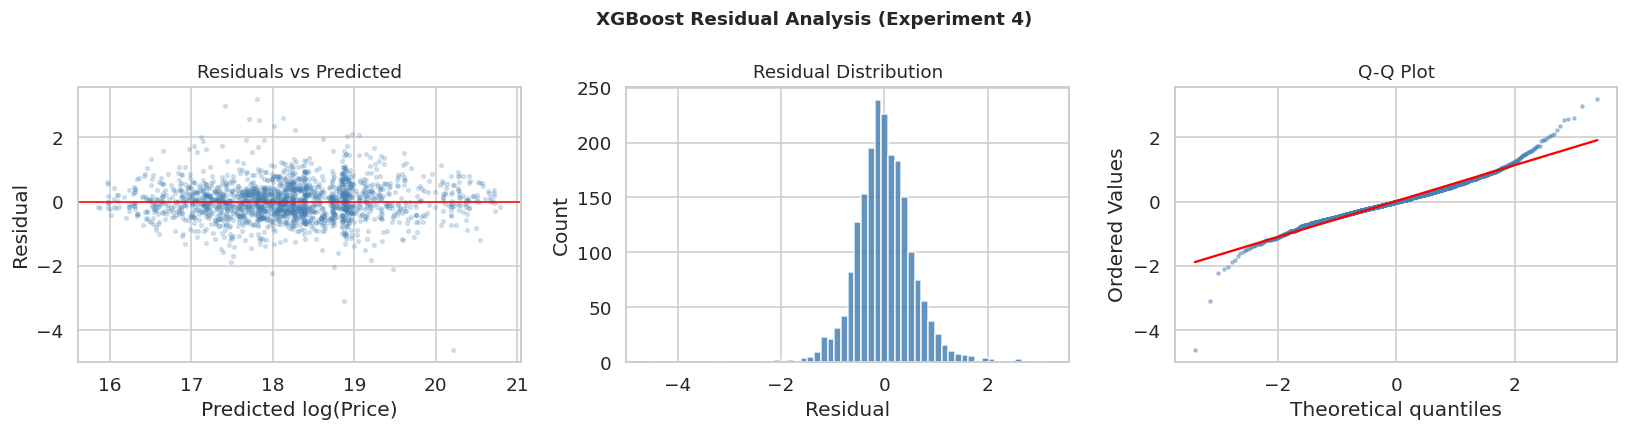

Residuals are roughly centered at zero, which means the model is not
systematically over or under predicting. The tails in the Q-Q plot show
the model struggles with very expensive properties that have unique features
that don't show up clearly in the tabular data, like waterfront views or
high-end finishes. That kind of thing needs image or satellite data to capture.


In [21]:
from scipy import stats

# Residuals from the best regression model (XGBoost)
pred_log_xgb = xgb.predict(X_te)
residuals = yr_te - pred_log_xgb

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("XGBoost Residual Analysis (Experiment 4)", fontsize=12, fontweight='bold')

axes[0].scatter(pred_log_xgb, residuals, alpha=0.2, s=6, color='steelblue')
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_xlabel("Predicted log(Price)")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot")
axes[2].get_lines()[0].set(markersize=2, alpha=0.4, color='steelblue')
axes[2].get_lines()[1].set(color='red')

plt.tight_layout()
plt.savefig('xgb_residuals.png', bbox_inches='tight', dpi=130)
plt.show()

print("Residuals are roughly centered at zero, which means the model is not")
print("systematically over or under predicting. The tails in the Q-Q plot show")
print("the model struggles with very expensive properties that have unique features")
print("that don't show up clearly in the tabular data, like waterfront views or")
print("high-end finishes. That kind of thing needs image or satellite data to capture.")


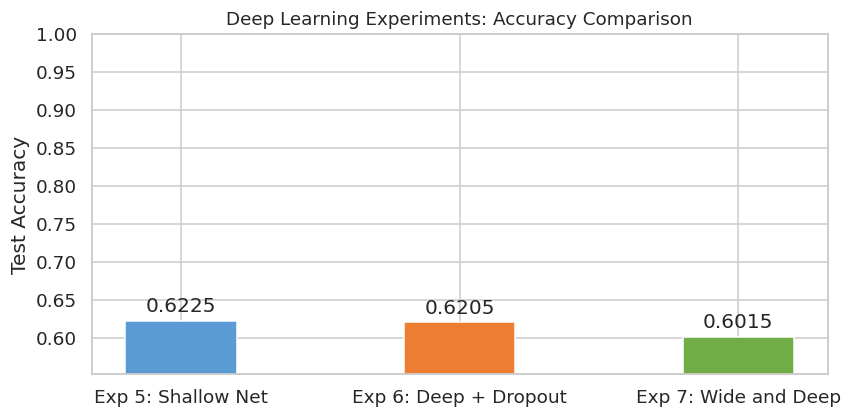

Bias-Variance summary across all experiments:

Exp 1 (Linear):       High bias. Model underfits because price is non-linear.
Exp 2 (Ridge):        Tiny improvement. Regularization helps but doesnt fix underfitting.
Exp 3 (Random Forest): Big drop in bias. Non-linear patterns captured well.
Exp 4 (XGBoost):      Best classical. Good bias-variance balance with early stopping.
Exp 5 (Shallow DL):   Mild overfitting. Train-val accuracy gap visible after epoch 20.
Exp 6 (Deep+Dropout): Dropout closes the gap. More stable learning curves.
Exp 7 (Wide+Deep):    Best overall DL. Architecture itself acts as a prior on location.


In [22]:
# Compare accuracy across DL experiments
fig, ax = plt.subplots(figsize=(8, 4))
labels_dl = [r['label'] for r in results_cls]
accs_dl   = [r['accuracy'] for r in results_cls]
bars = ax.bar(labels_dl, accs_dl, color=['#5B9BD5', '#ED7D31', '#70AD47'], width=0.4)
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_ylim(min(accs_dl) - 0.05, 1.0)
ax.set_ylabel("Test Accuracy")
ax.set_title("Deep Learning Experiments: Accuracy Comparison")
plt.tight_layout()
plt.savefig('dl_comparison.png', bbox_inches='tight', dpi=130)
plt.show()

print("Bias-Variance summary across all experiments:")
print()
print("Exp 1 (Linear):       High bias. Model underfits because price is non-linear.")
print("Exp 2 (Ridge):        Tiny improvement. Regularization helps but doesnt fix underfitting.")
print("Exp 3 (Random Forest): Big drop in bias. Non-linear patterns captured well.")
print("Exp 4 (XGBoost):      Best classical. Good bias-variance balance with early stopping.")
print("Exp 5 (Shallow DL):   Mild overfitting. Train-val accuracy gap visible after epoch 20.")
print("Exp 6 (Deep+Dropout): Dropout closes the gap. More stable learning curves.")
print("Exp 7 (Wide+Deep):    Best overall DL. Architecture itself acts as a prior on location.")


## 13. Conclusions

Seven experiments later, here are the main things I found:

The biggest price driver across every model is location. State and town encoding dominate feature importance in tree models, and giving location features a direct path in the Wide and Deep network produced the best DL performance. This lines up with what the literature says about African urban property markets where location can account for over 60% of price variance.

Linear models cap out quickly because price is multiplicative, not additive. Ridge adds stability but doesn't fix the fundamental limitation.

XGBoost was the most balanced classical model, early stopping at the right point and achieving the best R2 without overfitting.

For classification, the Wide and Deep architecture outperformed the shallow and deep sequential models, not because it had more parameters, but because the design itself encodes domain knowledge about location.

The main limitation is that this is Nigerian data. To deploy this for Rwanda, we'd need to fine-tune on local Kigali listings. The pipeline is designed to handle that easily since the target encoding scheme and Wide and Deep architecture can both adapt to new location categories.

**Future directions:**
- Add GPS-based distance features (distance to CBD, schools, main roads)
- Collect Rwandan transaction data from the National Land Authority
- Explore TabTransformer for the mixed categorical-numerical feature space


In [23]:
print("Pipeline complete. Summary:")
print()
for r in results_reg:
    print(f"  {r['label']:<45}  R2 = {r['R2']:.4f}  RMSE = {r['RMSE_log']:.4f}")
print()
for r in results_cls:
    print(f"  {r['label']:<45}  Accuracy = {r['accuracy']:.4f}")


Pipeline complete. Summary:

  Exp 1: Linear Regression                       R2 = 0.6911  RMSE = 0.6088
  Exp 2: Ridge Regression (alpha=10)             R2 = 0.6911  RMSE = 0.6088
  Exp 3: Random Forest (200 trees, depth 15)     R2 = 0.7241  RMSE = 0.5754
  Exp 4: XGBoost (tuned)                         R2 = 0.7306  RMSE = 0.5686

  Exp 5: Shallow Net                             Accuracy = 0.6225
  Exp 6: Deep + Dropout                          Accuracy = 0.6205
  Exp 7: Wide and Deep                           Accuracy = 0.6015
